# Traitement d'images: 
## en analyse non supervisée
## en analyse semi-supervisée

In [69]:
# === Data manipulation ===
import numpy as np
import pandas as pd

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# === Machine Learning===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, adjusted_rand_score, f1_score, precision_recall_curve,confusion_matrix,roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering

# === Computer Vision ===
import cv2

# === Deep Learning (PyTorch) ===
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

# === Deep Learning (TensorFlow / Keras) ===
import tensorflow as tf
keras = tf.keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.metrics import AUC, Precision, Recall, FalsePositives, FalseNegatives

# === NLP / Transformers ===
from transformers import pipeline, AutoTokenizer, AutoModel

import os
import random
import hashlib
from collections import defaultdict

print ("imports terminés")


imports terminés


## Analyse Exploratoire des données

In [2]:
print(os.listdir(r"data\mri_dataset_brain_cancer_oc"))

['avec_labels', "Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt", 'sans_label']


exploration visuelle

cv2, module Python de la bibliotheque OpenCV pour le traitement d'images

recheche d'images illisibles et verification des dimensions de tout le data set

In [3]:
dataset_path = "data/mri_dataset_brain_cancer_oc"
valid_ext = (".jpg", ".jpeg", ".png")

sizes = []
bad_images = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(valid_ext):
            continue

        img_path = os.path.join(root, file)

        img = cv2.imread(img_path)

        if img is None:
            bad_images.append(img_path)
            print("Image illisible :", img_path)
            continue

        sizes.append(img.shape)

print("\nNombre d'images illisibles :", len(bad_images))
print("Tailles uniques des images :", set(sizes))


Nombre d'images illisibles : 0
Tailles uniques des images : {(512, 512, 3)}


Vérification des doublons (par hashing, avec chunks pour economiser de la memoire)

hashing en sha256

In [4]:
dataset_path = r"data/mri_dataset_brain_cancer_oc"
valid_ext = (".png", ".jpg", ".jpeg")

hash_dict = defaultdict(list)

def get_hash(filepath):
    hasher = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(valid_ext):
            continue

        path = os.path.join(root, file)

        file_hash = get_hash(path)

        hash_dict[file_hash].append(path)


duplicates = {h: p for h, p in hash_dict.items() if len(p) > 1}

print("Nombre de groupes de doublons :", len(duplicates))

Nombre de groupes de doublons : 90


recherche du chemin des doublons concernés

In [5]:
for h, paths in duplicates.items():
    print("\nDoublon détecté :")
    for p in paths:
        print(p)


Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\11a7a426-4806-401e-98b2-b96e7094d1a6.jpg
data/mri_dataset_brain_cancer_oc\sans_label\f9466180-1e6b-4152-9176-6b4e2dc186ed.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\5af7f2cb-a82b-4635-865e-5b57dbc7a087.jpg
data/mri_dataset_brain_cancer_oc\sans_label\bd90cca9-a572-4464-b6fd-edb2af3e9a15.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\7e3f6acd-c9cc-440e-ba01-fedab0462fed.jpg
data/mri_dataset_brain_cancer_oc\sans_label\e9721e3a-e3c6-4a09-9b30-3c82b809069e.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\9ff6e310-b23a-4240-ac18-9fd99bd48e80.jpg
data/mri_dataset_brain_cancer_oc\sans_label\74486ecc-2beb-460d-89cb-50880e1a3daa.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\a8319ab8-471b-4d18-bb47-a377c4f9bd38.jpg
data/mri_dataset_brain_cancer_oc\sans_label\cf0cf298-45f4-4e43-a388-5a0d5f4b6095.jpg

Doublon détect

vérification visuelle des doublons (sur 3 groupes)

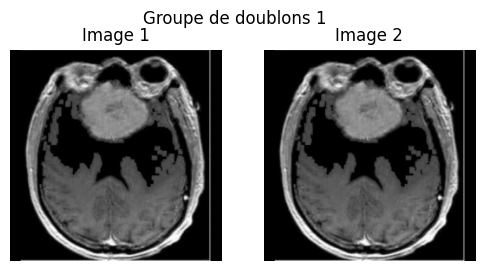

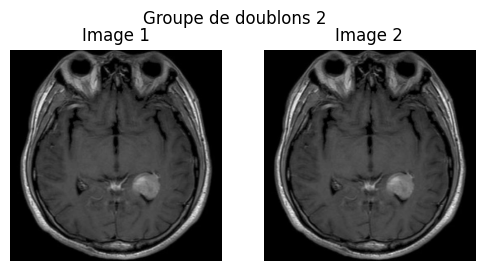

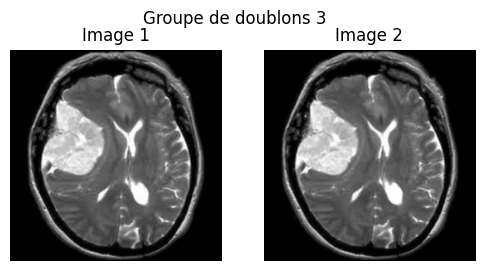

In [7]:
sample_duplicates = list(duplicates.items())[:3]

for i, (h, paths) in enumerate(sample_duplicates):

    n = len(paths)

    plt.figure(figsize=(3*n, 3))

    for j, path in enumerate(paths):

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, j+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {j+1}")

    plt.suptitle(f"Groupe de doublons {i+1}")
    plt.show()

=>les images identiques prouvent l'existence de doublons

Suppression des doublons: 3 cas possibles:

1_Si un doublon existe entre avec_labels et sans_label: on garde l'image avec_label;

2_Si les doublons sont dans le même dossier (avec_labels): on garde la première image;

3_Si les doublons sont dans le même dossier (sans_label): on garde la première image.

In [8]:
deleted = 0

for paths in duplicates.values():

    labeled = [p for p in paths if "avec_labels" in p]
    unlabeled = [p for p in paths if "sans_label" in p]

    # CAS 1 : doublon entre labeled et unlabeled
    if len(labeled) > 0 and len(unlabeled) > 0:

        # garder la première image avec label
        keep = labeled[0]

        # supprimer toutes les unlabeled
        for p in unlabeled:
            os.remove(p)
            deleted += 1
            print("Supprimé (sans label doublon) :", p)

        # si plusieurs labeled, garder la première
        for p in labeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon labeled) :", p)

    # CAS 2 : uniquement labeled
    elif len(labeled) > 0:

        keep = labeled[0]

        for p in labeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon labeled) :", p)

    # CAS 3 : uniquement unlabeled
    else:

        keep = unlabeled[0]

        for p in unlabeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon unlabeled) :", p)

print("Total supprimé :", deleted)

Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\f9466180-1e6b-4152-9176-6b4e2dc186ed.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\bd90cca9-a572-4464-b6fd-edb2af3e9a15.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\e9721e3a-e3c6-4a09-9b30-3c82b809069e.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\74486ecc-2beb-460d-89cb-50880e1a3daa.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\cf0cf298-45f4-4e43-a388-5a0d5f4b6095.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\6e0979a9-aef4-4745-bc30-8a507398da26.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\3d09671b-9479-4ec9-a9cf-2934ad88657b.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\647895dc-e736-4a30-bc1b-71c5b3065b17.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc

détection d’outliers (images très sombres-intensité à 0, ou toutes blanches-intensité à 255, totalement illisibles)

In [9]:
means = []

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img = cv2.imread(os.path.join(class_path, img_name))

            if img is not None:
                means.append(img.mean())

print("\nStatistiques intensité pixels :")
print("Min :", np.min(means))
print("Max :", np.max(means))
print("Mean :", np.mean(means))


Statistiques intensité pixels :
Min : 14.945938110351562
Max : 136.21646881103516
Mean : 51.60526270688171


Histogramme des intensités (détection d’outliers)

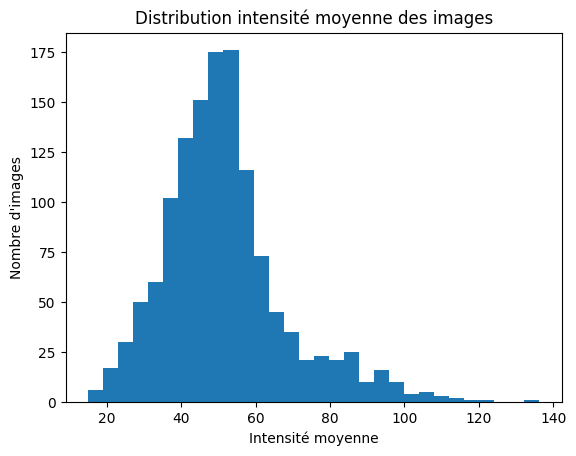

In [10]:
plt.hist(means, bins=30)
plt.title("Distribution intensité moyenne des images")
plt.xlabel("Intensité moyenne")
plt.ylabel("Nombre d'images")
plt.show()

=>on conserve toutes les images: pas d'images noires (0) ni blanches (255)

on fera une normalisation plus tard sur les images pour diminuer l'intensité

Explorer les données labelisées (distribution des classes)

In [11]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    if os.path.isdir(class_path):
        print(cls, ":", len(os.listdir(class_path)), "images")

cancer : 50 images
normal : 49 images


tailles des images sur **données labelisées**

In [12]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
valid_extensions = (".jpg", ".jpeg", ".png")

sizes = []

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        sizes.append(img.shape)

print("Tailles uniques trouvées :", set(sizes))

Tailles uniques trouvées : {(512, 512, 3)}


Affichage de quelques images labelisées par classe 

les pixels utilisent 3 canaux de couleur RGB

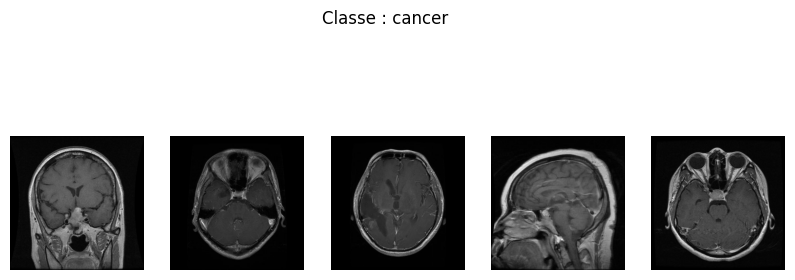

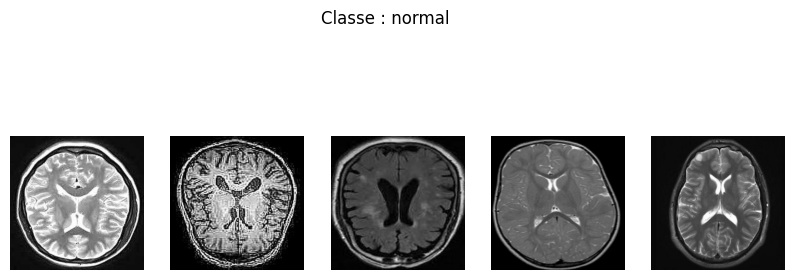

In [13]:
for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    plt.figure(figsize=(10, 4))
    
    for i in range(5):  
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"Classe : {cls}")
    plt.show()

Resize en taille standard pour ResNet : 224x224 (ResNet)

In [14]:
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224, 224))

print("Nouvelle taille :", img_resized.shape)

Nouvelle taille : (224, 224, 3)


definition de X et y à partir des images labelisées

In [15]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
img_size = 224

# Mapping : normal = 0, cancer = 1
CLASS_MAP = {"normal": 0, "cancer": 1}

X = []
y = []

classes = sorted(os.listdir(base_path))
print("Classes détectées :", classes)

for cls in classes:
    class_path = os.path.join(base_path, cls)

    if not os.path.isdir(class_path):
        continue

    label = CLASS_MAP.get(cls)
    if label is None:
        print(f"Classe inconnue ignorée : {cls}")
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        X.append(img)
        y.append(label)

Classes détectées : ['cancer', 'normal']


50 images "cancer" et 49 images "normal"

X, les images et y, les labels (0,1)

FN = prédit 0 (normal) alors que c'est 1 (cancer): cancer manqué (le plus critique)

FP = prédit 1 (cancer) alors que c'est 0 (normal): fausse alerte

normalisation en [0, 1] des pixels (de 0=noir à 255=blanc) pour stabiliser le modele

on évite l'explosion des gradients

In [16]:
X = np.array(X, dtype="float32") / 255.0   
y = np.array(y)
print(f"Distribution : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Dataset : {X.shape}, Labels : {y.shape}")

Distribution : {np.int64(0): np.int64(49), np.int64(1): np.int64(50)}
Dataset : (99, 224, 224, 3), Labels : (99,)


In [17]:
print("Mapping utilisé :", CLASS_MAP)
print("Labels uniques :", set(y))

Mapping utilisé : {'normal': 0, 'cancer': 1}
Labels uniques : {np.int64(0), np.int64(1)}


# analyse non supervisée

on va regarder si les images se partagent bien en 2 groupes (normal devrait etre séparé de cancer)

transformation des images en vecteur

In [18]:
X_features = X.reshape(X.shape[0], -1)

print(X_features.shape)

(99, 150528)


Standardisation des features avant réduction de dimension et clustering

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

Réduction de dimension avec PCA

In [ ]:
# garde 95% de la variance (si trop grande image=peu de variance)
pca = PCA(n_components=0.95, random_state=42) 
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print(f"Composantes retenues : {pca.n_components_}")
print(f"Variance expliquée   : {pca.explained_variance_ratio_.sum()*100:.1f}%")

(99, 68)
Composantes retenues : 68
Variance expliquée   : 95.2%


Visualisation avec t-SNE en 2D

In [50]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

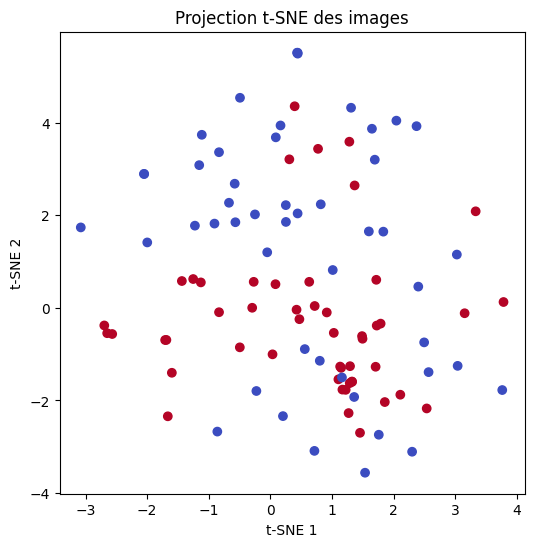

In [51]:
plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="coolwarm")
plt.title("Projection t-SNE des images")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

Clustering avec K-Means

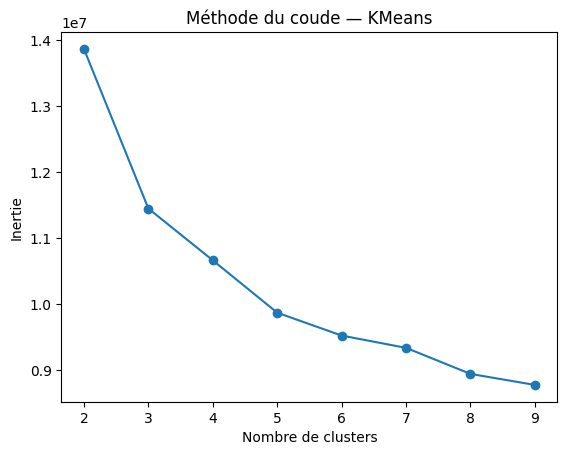

In [53]:
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker="o")
plt.title("Méthode du coude — KMeans")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

on a bien 2 clusters

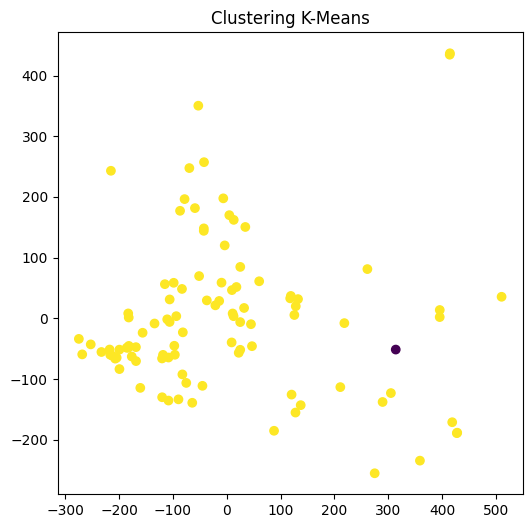

In [55]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_pca)
plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_kmeans, cmap="viridis")
plt.title("Clustering K-Means")
plt.show()

=> 2 groupes totalement très inégaux sur les 100 images =>pertinence très faible

Score ARI (Adjusted Rand Index)
comparaison clusters trouvés vs labels réels

ARI par K‑Means

In [67]:
ari_KMeans = adjusted_rand_score(y, clusters_kmeans)

print("ARI score clusters_kmeans:", ari_KMeans)

ARI score clusters_kmeans: -0.0004042037186742118


=> clustering très mauvais

Clustering avec DBSCAN

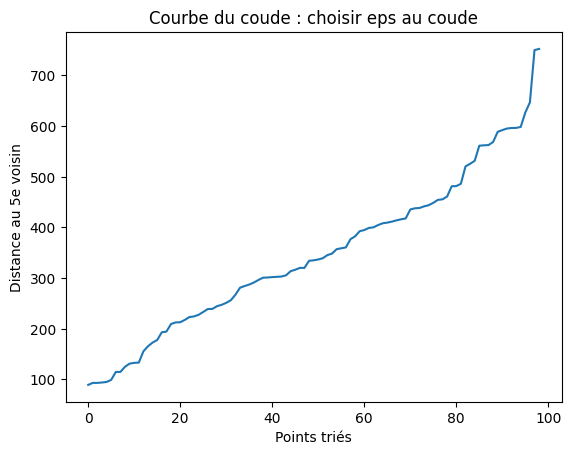

In [68]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title("Courbe du coude : choisir eps au coude")
plt.xlabel("Points triés")
plt.ylabel("Distance au 5e voisin")
plt.show()

In [ ]:
dbscan = DBSCAN(eps=90, min_samples=3)  # on choisit 90
clusters_db = dbscan.fit_predict(X_pca)

# Vérifie que DBSCAN ne met pas tout dans le bruit (-1)
print("Clusters DBSCAN uniques :", np.unique(clusters_db))
print("Points bruit (-1) :", (clusters_db == -1).sum())

Clusters DBSCAN uniques : [-1  0]
Points bruit (-1) : 93


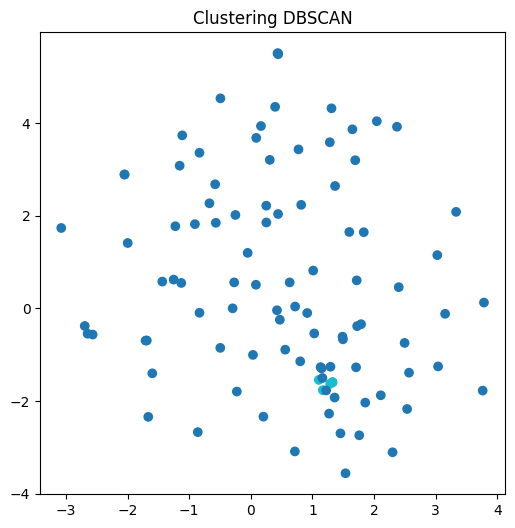

In [65]:
dbscan = DBSCAN(eps=90, min_samples=5)

clusters_db = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_db, cmap="tab10")
plt.title("Clustering DBSCAN")
plt.show()

In [66]:
ari_dbscan = adjusted_rand_score(y, clusters_db)

print("ARI DBSCAN:", ari_dbscan)

ARI DBSCAN: 0.006237607402511567


=>données trop uniformément distribuées dans l'espace PCA pour que DBSCAN trouve des Z denses

=>on va tester plutôt AgglomerativeClustering:

ARI Agglomeratif: 0.09102617366015787


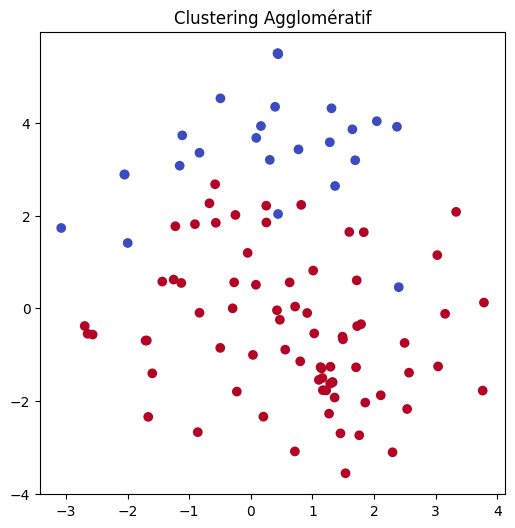

In [70]:
agglo = AgglomerativeClustering(n_clusters=2)
clusters_agglo = agglo.fit_predict(X_pca)

ari_agglo = adjusted_rand_score(y, clusters_agglo)
print("ARI Agglomeratif:", ari_agglo)

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_agglo, cmap="coolwarm")
plt.title("Clustering Agglomératif")
plt.show()

=>meilleur ARI (sans être exceptionnel) et 2 clusters visibles

# analyse semi supervisee:

SPLIT TRAIN_TEST 

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

num_classes = len(classes)
print("Nombre de classes :", num_classes)

Train : (79, 224, 224, 3)
Test : (20, 224, 224, 3)
Nombre de classes : 2


# CNN 

creation d'un jeu de neurones avec Keras

In [32]:
model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)), # 32 filtres
    layers.MaxPooling2D(2,2), # reduction en 2x2

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(), # on aplatit le 2D en 1D
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5), # desactivation de 50% de neurones contre l'overfit

    layers.Dense(1,activation="sigmoid") # proba d'image cancer
])


c:\Users\chris\traitement_images_semi_supervisées\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


on cherche à minimiser les mauvaises predictions=> loss function
modele de classification=> en binary_crossentropy

In [33]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

flatten a généré un vecteur de 86528 valeurs (provenant de 26x26x128 de la derniere couche)

In [35]:
print(y_train.shape)
print(np.unique(y_train))

(79,)
[0 1]


entraînement

In [36]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4085 - fn: 31.0000 - fp: 11.0000 - loss: 1.6219 - precision: 0.3889 - recall: 0.1842 - roc_auc: 0.4270 - val_accuracy: 0.2500 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 1.0408 - val_precision: 0.2500 - val_recall: 1.0000 - val_roc_auc: 0.1667
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5775 - fn: 2.0000 - fp: 28.0000 - loss: 0.7268 - precision: 0.5625 - recall: 0.9474 - roc_auc: 0.4940 - val_accuracy: 0.6250 - val_fn: 0.0000e+00 - val_fp: 3.0000 - val_loss: 0.6885 - val_precision: 0.4000 - val_recall: 1.0000 - val_roc_auc: 0.7500
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 655ms/step - accuracy: 0.7324 - fn: 7.0000 - fp: 12.0000 - loss: 0.6735 - precision: 0.7209 - recall: 0.8158 - roc_auc: 0.7616 - val_accuracy: 0.6250 - val_fn: 2.0000 - val_fp: 1.0000 - val_loss: 0.5665 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8333
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6

metriques

particularité du calcul du f1_sccore non supporté par toutes les versions de Keras:
calcul manuel entre precision et recall

In [37]:
loss, accuracy, roc_auc, precision, recall, fp, fn = model.evaluate(X_test, y_test, verbose=0)

f1 = 2 * (precision * recall) / (precision + recall + 1e-7)  # 1e-7 pour éviter division par zéro

print(f"Baseline accuracy : {accuracy*100:.2f}%")
print(f"Loss              : {loss:.4f}")
print(f"ROC AUC           : {roc_auc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"Faux Positifs     : {int(fp)}")
print(f"Faux Négatifs     : {int(fn)}")

Baseline accuracy : 80.00%
Loss              : 0.4993
ROC AUC           : 0.8300
Precision         : 0.8750
Recall            : 0.7000
F1 Score          : 0.7778
Faux Positifs     : 1
Faux Négatifs     : 3


matrice de confusion

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step


<Axes: >

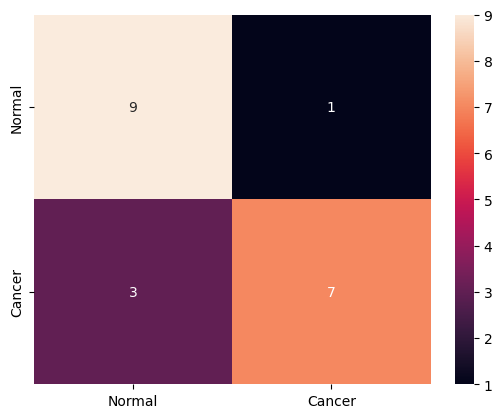

In [38]:
y_proba = model.predict(X_test) # proba prédite d'une image cancer
y_pred = (y_proba > 0.5).astype(int).flatten() # correspondance probas avec la classe prédite 0 ou 1

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal","Cancer"],
            yticklabels=["Normal","Cancer"])

Courbe ROC-AUC

Text(0.5, 1.0, 'ROC Curve')

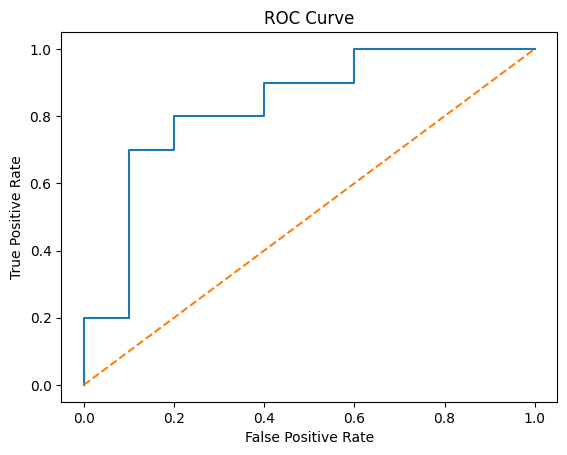

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

data augmentation car seulement 99 echantillons avac labels (éviter overfit)

In [40]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

transfer learning avec ResNet50, modèle pré-entraîné.

In [41]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # ResNet déjà multi-entraîné; seules les couches ajoutées (Dense, Dropout) seront entraînées

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

pour stabiliser le dataset de seulement 99 images labelisées, on modifie y

In [42]:
y = np.array(y).astype("float32")

In [43]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.4684 - fn: 25.0000 - fp: 17.0000 - loss: 0.8152 - precision: 0.4688 - recall: 0.3750 - roc_auc: 0.4897 - val_accuracy: 0.7000 - val_fn: 5.0000 - val_fp: 1.0000 - val_loss: 0.6167 - val_precision: 0.8333 - val_recall: 0.5000 - val_roc_auc: 0.8700
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 748ms/step - accuracy: 0.6203 - fn: 12.0000 - fp: 18.0000 - loss: 0.6882 - precision: 0.6087 - recall: 0.7000 - roc_auc: 0.6237 - val_accuracy: 0.7000 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 0.5845 - val_precision: 0.6250 - val_recall: 1.0000 - val_roc_auc: 0.8850
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 828ms/step - accuracy: 0.5823 - fn: 15.0000 - fp: 18.0000 - loss: 0.6469 - precision: 0.5814 - recall: 0.6250 - roc_auc: 0.6657 - val_accuracy: 0.7000 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 0.5666 - val_precision: 0.6250 - val_recall: 1.0000 - val_roc_auc: 0.8850
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 933ms/step - accu

predictions sur images sans label

In [44]:
unlabeled_path = "data/mri_dataset_brain_cancer_oc/sans_label"

X_unlabeled = []

for img_name in os.listdir(unlabeled_path):
    img_path = os.path.join(unlabeled_path, img_name)
    img = cv2.imread(img_path)
    
    if img is None:
        continue
    
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    X_unlabeled.append(img)

X_unlabeled = np.array(X_unlabeled, dtype="float32") / 255.0

print("Unlabeled shape:", X_unlabeled.shape)

Unlabeled shape: (1311, 224, 224, 3)


modele semi supervise

le modele renvoie une probabilité entre 0 et 1 pour chaque image non labelisée

In [45]:
THRESHOLD = 0.9
pseudo_probs = model.predict(X_unlabeled)

41/41 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step


on garde les prédictions très confiantes:
-predictions >0.9 (classe 1)
-predictions <0.1 (classe 0)
-les autres ne sont pas conservées

In [46]:
mask = (pseudo_probs > THRESHOLD) | (pseudo_probs < (1 - THRESHOLD))

X_pseudo = X_unlabeled[mask.flatten()] # images retenues dont le modèle est très confiant

Création des pseudo‑labels (O si proba <=0.5, 1 sinon)

In [47]:
y_pseudo = (pseudo_probs[mask.flatten()] > 0.5).astype(int).flatten()

print(f"Pseudo labels retenus : {len(y_pseudo)}")
print(f"Distribution : {np.unique(y_pseudo, return_counts=True)}")

Pseudo labels retenus : 51
Distribution : (array([0]), array([51]))


In [ ]:
print("y_train shape:", y_train.shape) # vrais labels
print("y_pseudo shape:", y_pseudo.shape) # labels predits

y_train shape: (79,)
y_pseudo shape: (51,)


concaténation des pseudo-labels avec les vrais labels

In [49]:
X_combined = np.concatenate([X_train, X_pseudo])
y_combined = np.concatenate([y_train, y_pseudo])

print(X_combined.shape)
print(y_combined.shape)

(130, 224, 224, 3)
(130,)


entrainement à nouveau

In [50]:
history_ssl = model.fit(
    X_combined, y_combined,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=8
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 705ms/step - accuracy: 0.8846 - fn: 6.0000 - fp: 9.0000 - loss: 0.2997 - precision: 0.7907 - recall: 0.8500 - roc_auc: 0.9392 - val_accuracy: 0.7000 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 0.4929 - val_precision: 0.6250 - val_recall: 1.0000 - val_roc_auc: 0.8750
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 635ms/step - accuracy: 0.8923 - fn: 3.0000 - fp: 11.0000 - loss: 0.2747 - precision: 0.7708 - recall: 0.9250 - roc_auc: 0.9475 - val_accuracy: 0.8500 - val_fn: 0.0000e+00 - val_fp: 3.0000 - val_loss: 0.4389 - val_precision: 0.7692 - val_recall: 1.0000 - val_roc_auc: 0.8800
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 654ms/step - accuracy: 0.8923 - fn: 4.0000 - fp: 10.0000 - loss: 0.3354 - precision: 0.7826 - recall: 0.9000 - roc_auc: 0.9183 - val_accuracy: 0.8000 - val_fn: 0.0000e+00 - val_fp: 4.0000 - val_loss: 0.4561 - val_precision: 0.7143 - val_recall: 1.0000 - val_roc_auc: 0.8950
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 690ms/step 

In [51]:
print("Nombre pseudo-labels retenus :", len(X_pseudo))

Nombre pseudo-labels retenus : 51


on retire les données pseudo‑labellisées du pool non‑labellisé restant

In [52]:
X_unlabeled_restant = X_unlabeled[~mask.flatten()]  # ce qui reste après le pseudo-labeling
print("Unlabeled restant :", X_unlabeled_restant.shape)

Unlabeled restant : (1260, 224, 224, 3)


entrainement successif

In [53]:
def semi_supervised_training(
    model,
    X_train,
    y_train,
    X_unlabeled,
    X_test,
    y_test,
    confidence_threshold=0.95,
    iterations=5,
    batch_size=8,
    epochs=5
):

    X_labeled = X_train.copy()
    y_labeled = y_train.copy()

    for i in range(iterations):

        print(f"\n===== Iteration {i+1} =====")

        # prédictions sur données non labelisées
        preds = model.predict(X_unlabeled)

        # sélection forte confiance
        high_conf_mask = (preds > confidence_threshold) | (preds < (1 - confidence_threshold))

        X_pseudo = X_unlabeled[high_conf_mask.flatten()]
        y_pseudo = (preds[high_conf_mask] > 0.5).astype(int).flatten()

        print(f"Pseudo labels retenus : {len(y_pseudo)}")

        if len(y_pseudo) == 0:
            print("Aucun pseudo label fiable, arrêt.")
            break

        # ajout au dataset
        X_labeled = np.concatenate([X_labeled, X_pseudo])
        y_labeled = np.concatenate([y_labeled, y_pseudo])

        # retirer ces images du pool non labelisé
        X_unlabeled = X_unlabeled[~high_conf_mask.flatten()]

        print(f"Dataset train actuel : {X_labeled.shape}")

        # réentrainement
        model.fit(
            X_labeled,
            y_labeled,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        # évaluations succesives
        loss, acc, roc_auc, precision, recall, fp, fn = model.evaluate(X_test, y_test, verbose=0)

        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

        print(f"Loss      : {loss:.4f}")
        print(f"Accuracy  : {acc:.4f}")
        print(f"ROC AUC   : {roc_auc:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1 Score  : {f1:.4f}")
        print(f"Faux Positifs : {int(fp)}")
        print(f"Faux Négatifs : {int(fn)}")
                
    return model

modele entrainé et élargi (label et pseudo-label) sur X_combined

y_combined considéré comme y_train de départ

X_unlabeled_restant: seulement sur les sans-labels restants (pas encore pseudo-labelisés)

lancement de la fonction:

In [54]:
model = semi_supervised_training(
    model=model,                        
    X_train=X_combined,                 
    y_train=y_combined,                 
    X_unlabeled=X_unlabeled_restant,    
    X_test=X_test,
    y_test=y_test,
    confidence_threshold=0.95,
    iterations=10,
    epochs=5
)


===== Iteration 1 =====
40/40 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step
Pseudo labels retenus : 57
Dataset train actuel : (187, 224, 224, 3)
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 560ms/step - accuracy: 0.9091 - fn: 4.0000 - fp: 13.0000 - loss: 0.2097 - precision: 0.7347 - recall: 0.9000 - roc_auc: 0.9595
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 596ms/step - accuracy: 0.9198 - fn: 5.0000 - fp: 10.0000 - loss: 0.1866 - precision: 0.7778 - recall: 0.8750 - roc_auc: 0.9674
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 520ms/step - accuracy: 0.9198 - fn: 5.0000 - fp: 10.0000 - loss: 0.2001 - precision: 0.7778 - recall: 0.8750 - roc_auc: 0.9618
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 566ms/step - accuracy: 0.9251 - fn: 2.0000 - fp: 12.0000 - loss: 0.2061 - precision: 0.7600 - recall: 0.9500 - roc_auc: 0.9581
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 575ms/step - accuracy: 0.9144 - fn: 6.0000 - fp: 10.0000 - loss: 0.1773 - precision: 0.7727 - recall: 0.8500 - roc_auc: 0.9673
Loss      : 0.4307
Accuracy

Graphique accuracy avant vs apres pseudo-label

Text(0, 0.5, 'Accuracy')

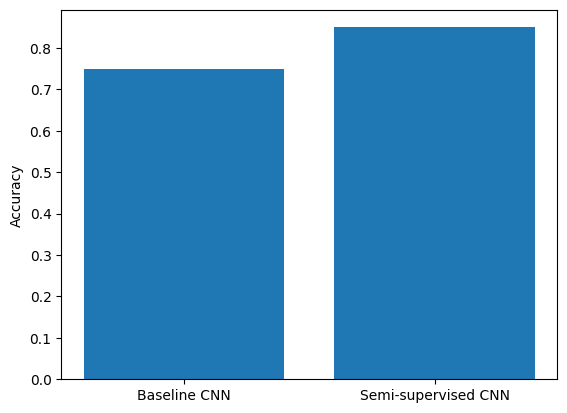

In [57]:
models = ["Baseline CNN", "Semi-supervised CNN"]
scores = [0.75, 0.85]

plt.bar(models, scores)
plt.ylabel("Accuracy")

Distribution des probabilités

Text(0.5, 1.0, 'Distribution des probabilités')

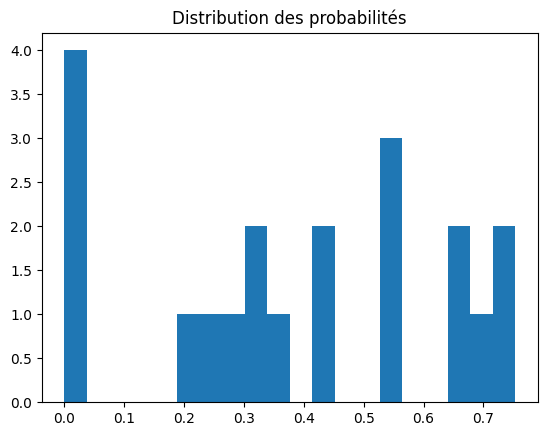

In [56]:
plt.hist(y_proba, bins=20)
plt.title("Distribution des probabilités")